# Nexqori · servicios que necesita la base
**Censo sintético histórico, consultado el 28 de septiembre de 2026.**
La prioridad propuesta es cuentas/tarjetas, movimientos, transferencias, pagos y continuidad de solicitudes.
Las cifras describen el dataset; no prueban demanda real, causas, conversión o impacto.
Este cuaderno usa agregados sin identificadores de clientes. El script
scripts/analizar_servicios_nexqori.py contiene las 18 consultas completas de sólo lectura.
El manifiesto registra SQL, versiones, huellas SHA-256 y 13 comprobaciones.

In [1]:
from pathlib import Path
import hashlib,json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=Path.cwd() if (Path.cwd()/'package.json').exists() else Path.cwd().parent
DATA=ROOT/'notebooks/servicios_nexqori'
FIG=ROOT/'docs/figures'
FIG.mkdir(parents=True,exist_ok=True)
manifest=json.loads((DATA/'analysis.json').read_text(encoding='utf-8'))
assert all(manifest['metadata']['checks'].values())
for name,expected in manifest['metadata']['result_sha256'].items():
    assert hashlib.sha256((DATA/name).read_bytes()).hexdigest()==expected,name
frames={p.stem:pd.read_csv(p) for p in DATA.glob('*.csv')}
q=frames['quality'].iloc[0]
display(pd.DataFrame([{'control':k,'resultado':'PASS' if v else 'FAIL'} for k,v in manifest['metadata']['checks'].items()]))
display(frames['quality'].T)

,control,resultado
0,product_total,PASS
1,transactions_total,PASS
2,digital_total,PASS
3,contacts_total,PASS
4,complaints_total,PASS
5,country_join,PASS
6,product_join,PASS
7,monthly_transactions,PASS
8,monthly_events,PASS
9,valid_owner_join,PASS


,0
customers,150000
products,400000
product_owners,139578
transactions,4425008
digital_events,15620994
interactions,686296
complaints,67095
anonymous_events,3745446
missing_actions,1561432
transaction_owner_mismatches,0


## Cobertura y unidades
150.000 clientes, 400.000 productos, 4.425.008 transacciones, 15.620.994 eventos,
686.296 interacciones de atención y 67.095 reclamos. El censo previo completo abarca 13 tablas y
23.495.188 filas. Productos es una fotografía; transacciones y eventos son registros históricos.
El alcance de clientes es distinto por grupo y **no se suma** entre grupos.

Transacciones y eventos: 2023-06-17 a 2026-06-18, sin zona horaria declarada en el origen.
Junio de 2023 y junio de 2026 son parciales y no permiten comparar meses completos.

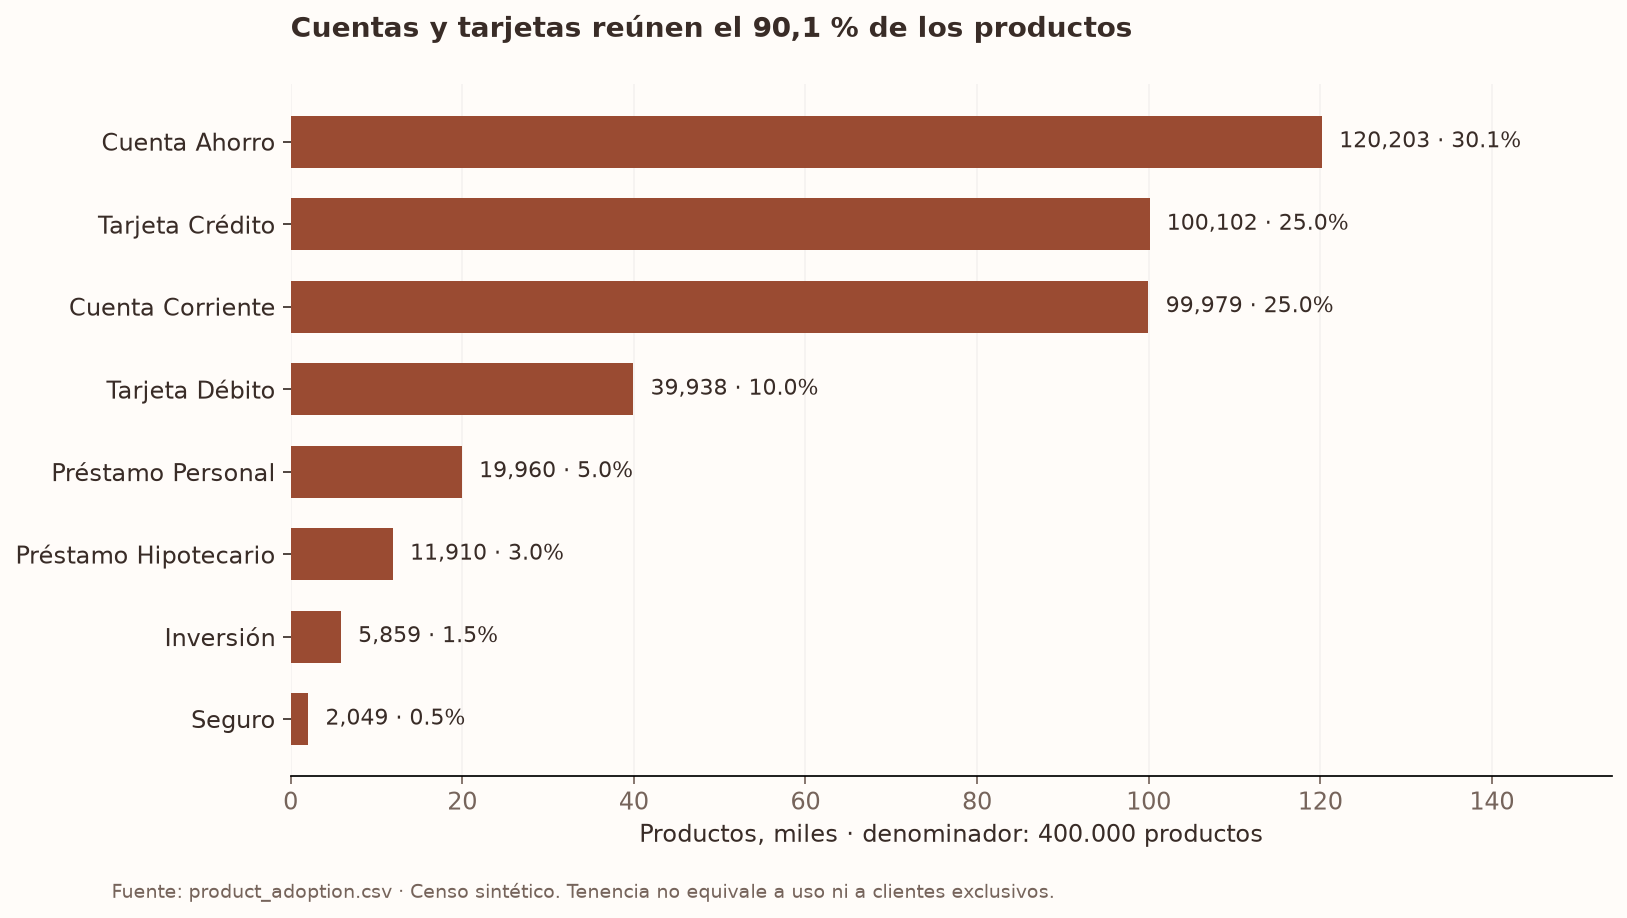

,product_type,products,customers,active_products,linked_app_products,product_share_pct,customer_reach_pct
0,Cuenta Ahorro,120203,82695,102148,59976,30.05075,55.130000
1,Tarjeta Crédito,100102,73177,85090,50073,25.02550,48.784667
2,Cuenta Corriente,99979,72843,85079,49956,24.99475,48.562000
3,Tarjeta Débito,39938,35015,33749,19830,9.98450,23.343333
4,Préstamo Personal,19960,18615,16977,9959,4.99000,12.410000
5,Préstamo Hipotecario,11910,11417,10157,6067,2.97750,7.611333
6,Inversión,5859,5750,5022,2978,1.46475,3.833333
7,Seguro,2049,2036,1743,1019,0.51225,1.357333


In [2]:
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'figure.facecolor':'#FFFCF9',
'axes.facecolor':'#FFFCF9','text.color':'#392C27','axes.labelcolor':'#392C27',
'xtick.color':'#76645B','ytick.color':'#392C27','axes.spines.top':False,'axes.spines.right':False,'axes.spines.left':False})
def savefig(fig,name):
    fig.savefig(FIG/name,dpi=155,bbox_inches='tight',facecolor='#FFFCF9')
    plt.close(fig)
    display(Image(filename=str(FIG/name)))
p=frames['product_adoption'].sort_values('products')
fig,ax=plt.subplots(figsize=(11,5.8))
bars=ax.barh(p.product_type,p.products/1000,color='#9A4B32',height=.63)
ax.bar_label(bars,labels=[f'{n:,.0f} · {share:.1f}%' for n,share in zip(p.products,p.product_share_pct)],padding=8,fontsize=10)
ax.set_xlim(0,154);ax.set_xlabel('Productos, miles · denominador: 400.000 productos')
ax.set_title('Cuentas y tarjetas reúnen el 90,1 % de los productos',loc='left',fontweight='bold',pad=22)
ax.grid(axis='x',alpha=.12);ax.set_axisbelow(True)
fig.text(.02,-.025,'Fuente: product_adoption.csv · Censo sintético. Tenencia no equivale a uso ni a clientes exclusivos.',fontsize=9,color='#76645B')
savefig(fig,'productos.png')
display(frames['product_adoption'])

Cuenta de ahorro llega al 55,13 % de los 150.000 clientes y tarjeta de crédito al 48,78 %;
pueden ser las mismas personas. 139.578 clientes tienen al menos un producto.
La vinculación de una app no prueba actividad reciente. La base necesita cuentas y tarjetas
separadas, saldos por moneda, historial propio y acceso a los demás servicios.

,transactions,customers,share_pct,declined_pct,share_recent_pct,difference_pp
transaction_type,,,,,,
Purchase,1083406,82134,24.484,5.036,24.427,-0.057
Withdrawal,964673,127531,21.800,4.967,21.799,-0.002
Transfer,896438,112914,20.258,5.018,20.221,-0.037
Payment,738964,125736,16.700,4.987,16.813,0.114
Deposit,609409,104719,13.772,4.962,13.805,0.033
Adjustment,132118,29746,2.986,5.062,2.935,-0.051


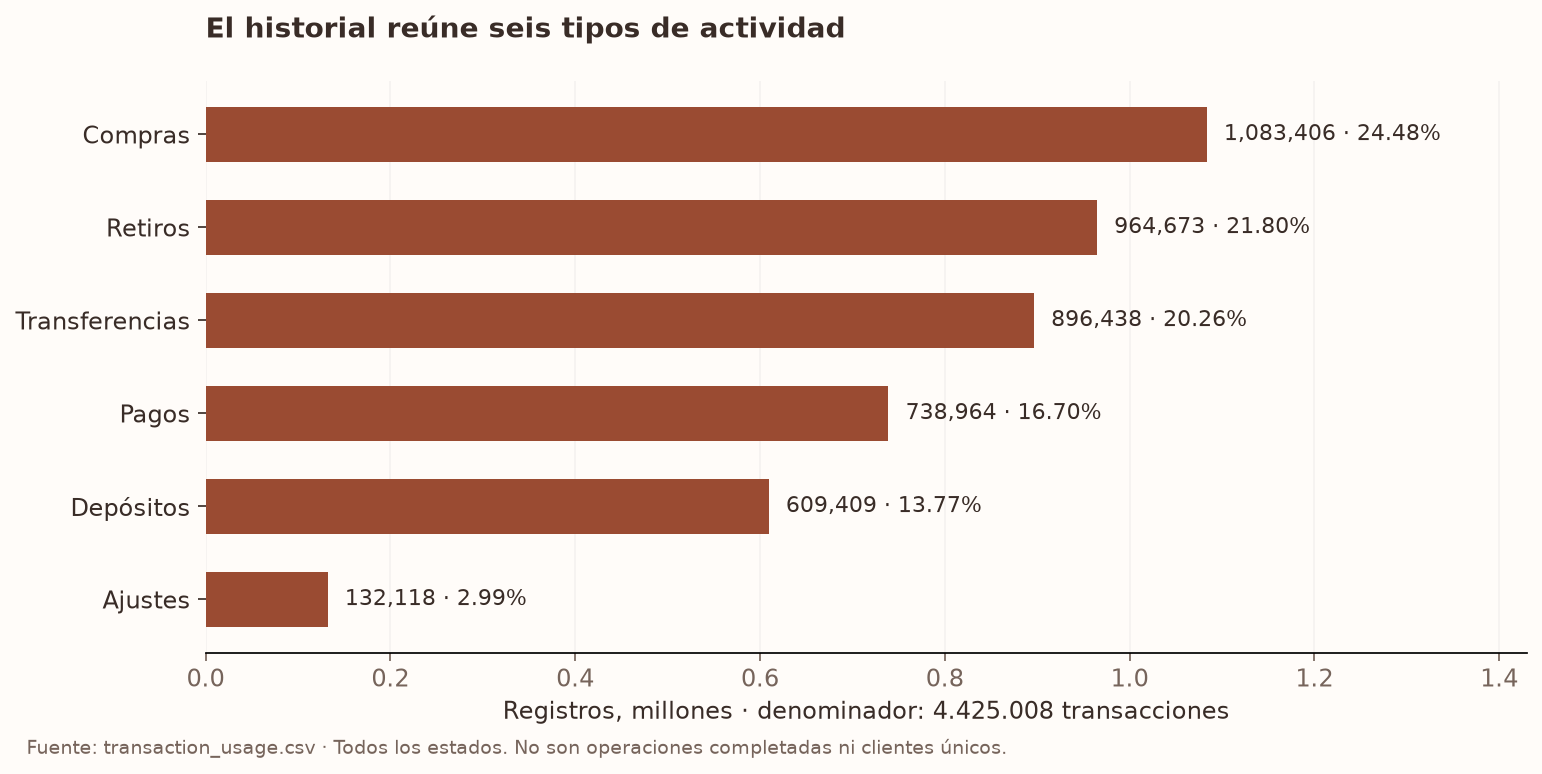

country,Argentina,Colombia,México
transaction_type,,,
Adjustment,2.997,2.948,3.004
Deposit,13.758,13.807,13.756
Payment,16.686,16.651,16.734
Purchase,24.523,24.522,24.445
Transfer,20.219,20.246,20.281
Withdrawal,21.817,21.826,21.779


Mayor diferencia entre países (puntos porcentuales): 0.084


,source_table,status_label,records
0,products,Closed,32039
1,products,Active,339965
2,products,Blocked,19935
3,products,Suspended,8061
4,transactions,Reversed,44750
5,transactions,Declined,221234
6,transactions,Pending,88343
7,transactions,Approved,4070681


,channel,transaction_type,transactions,customers,declined
0,ATM,Purchase,325993,78580,16579
1,ATM,Withdrawal,289518,105342,14290
2,ATM,Transfer,268811,94788,13390
3,ATM,Payment,221647,92454,11016
4,ATM,Deposit,182775,81101,9010
5,ATM,Adjustment,39590,21624,2019
6,App,Purchase,162618,66711,8148
7,App,Withdrawal,144402,79322,7040
8,App,Transfer,134801,72483,6756
9,App,Payment,110413,65728,5507


,product_type,transaction_type,transactions,customers
0,Cuenta Ahorro,Transfer,465507,73583
1,Cuenta Ahorro,Withdrawal,399588,73066
2,Cuenta Ahorro,Deposit,332203,72111
3,Cuenta Ahorro,Payment,132835,58820
4,Cuenta Corriente,Transfer,386990,64311
5,Cuenta Corriente,Withdrawal,332693,63870
6,Cuenta Corriente,Deposit,277206,62996
7,Cuenta Corriente,Payment,110234,50631
8,Inversión,Payment,39121,4941
9,Inversión,Adjustment,19577,4853


In [3]:
tx=frames['transaction_usage'].set_index('transaction_type')
recent=frames['transaction_recent'].set_index('transaction_type')
comparison=tx[['transactions','customers','share_pct','declined_pct']].join(recent[['share_pct']].rename(columns={'share_pct':'share_recent_pct'}))
comparison['difference_pp']=comparison.share_recent_pct-comparison.share_pct
display(comparison.round(3))
names={'Purchase':'Compras','Withdrawal':'Retiros','Transfer':'Transferencias','Payment':'Pagos','Deposit':'Depósitos','Adjustment':'Ajustes'}
t=tx.sort_values('transactions')
fig,ax=plt.subplots(figsize=(11,4.8))
bars=ax.barh([names[k] for k in t.index],t.transactions/1e6,color='#9A4B32',height=.6)
ax.bar_label(bars,labels=[f'{n:,.0f} · {share:.2f}%' for n,share in zip(t.transactions,t.share_pct)],padding=8,fontsize=10)
ax.set_xlim(0,1.43);ax.set_xlabel('Registros, millones · denominador: 4.425.008 transacciones')
ax.set_title('El historial reúne seis tipos de actividad',loc='left',fontweight='bold',pad=20)
ax.grid(axis='x',alpha=.12);ax.set_axisbelow(True)
fig.text(.02,-.025,'Fuente: transaction_usage.csv · Todos los estados. No son operaciones completadas ni clientes únicos.',fontsize=9,color='#76645B')
savefig(fig,'actividad.png')
country=frames['transaction_country'].pivot(index='transaction_type',columns='country',values='country_share_pct')
display(country.round(3))
print('Mayor diferencia entre países (puntos porcentuales):',round((country.max(axis=1)-country.min(axis=1)).max(),3))
display(frames['status_domains'])
display(frames['transaction_channel'])
display(frames['transaction_product'])

El mix de marzo–mayo de 2026, tres meses completos, difiere menos de 0,12 puntos porcentuales
del histórico por tipo. La similitud entre países pertenece a este dataset sintético;
no es evidencia para ofertas ni preferencias regionales reales.
El origen usa Approved, Declined, Pending y Reversed, no Completed. Los totales incluyen todos los estados.
POS y ATM están incluidos: volumen bancario total no equivale a actividad digital.

In [4]:
display(frames['digital_action'])
pairs=frames['digital_action_type']
auth=pairs[pairs.action_name.isin(['login','logout'])]
bad=auth[((auth.action_name=='login')&(auth.event_type=='Logout'))|((auth.action_name=='logout')&(auth.event_type=='Login'))]
print('Eventos anónimos (%):',round(100*q.anonymous_events/q.digital_events,3))
print('Acciones ausentes (%):',round(100*q.missing_actions/q.digital_events,3))
print('Login/logout contradictorios:',int(bad.events.sum()),'de',int(auth.events.sum()))
display(pairs[pairs.action_name.isin(['initiate_transfer','initiate_payment'])])
display(frames['digital_channel'])
display(frames['digital_pages'])

,action_name,events,identified_customers,sessions,anonymous_events,errors,share_pct
0,view_product,3407643,149889,1381335,817349,0,21.814508
1,logout,2191640,149916,1418993,525484,0,14.030093
2,login,2189929,149897,1417805,525559,0,14.019140
3,(sin acción),1561432,149203,1017911,374571,35647,9.995728
4,initiate_payment,902225,145389,678703,216178,53657,5.775721
5,initiate_transfer,901824,145384,678531,215999,53883,5.773154
6,view_transactions,901039,145380,678342,216555,54073,5.768128
7,view_accounts,892802,145145,673221,213850,40308,5.715398
8,view_products,891777,145351,673387,213722,40193,5.708836
9,view_help,890625,145133,672600,213090,40679,5.701462


Eventos anónimos (%): 23.977
Acciones ausentes (%): 9.996
Login/logout contradictorios: 2190252 de 4381569


,action_name,event_type,events
7,initiate_payment,PageView,597645
8,initiate_payment,FormSubmit,178918
9,initiate_payment,Purchase,72005
10,initiate_payment,Error,53657
11,initiate_transfer,PageView,597058
12,initiate_transfer,FormSubmit,178964
13,initiate_transfer,Purchase,71919
14,initiate_transfer,Error,53883


,channel,events,identified_customers,anonymous_events,errors
0,Android App,5476164,145247,1309237,125974
1,iOS App,3899497,136908,933954,89294
2,Desktop Web,3128851,128771,752875,71817
3,Mobile Web,3116482,128569,749380,71638


,page_title,events,identified_customers
0,Cerrar Sesión,2312841,149929
1,Iniciar Sesión,2312796,149916
2,Préstamos,1199615,147845
3,Cuenta de Ahorro,1198585,147899
4,Tarjeta de Crédito,1198485,147876
5,Pagar Servicios,952401,145997
6,Transferir,951874,145947
7,Mis Movimientos,950599,145946
8,Mis Cuentas,942316,145781
9,Productos,941200,145947


Las etiquetas initiate_payment (902.225 eventos) e initiate_transfer (901.824) apoyan que ambas
rutas sean visibles. **No son pagos ni transferencias completados.** Casi 24 % de eventos son
anónimos y 10 % carecen de acción. Login/logout contradicen su tipo en aproximadamente la mitad de
sus registros: no calcular conversión o un embudo de autenticación sin reparar la semántica.

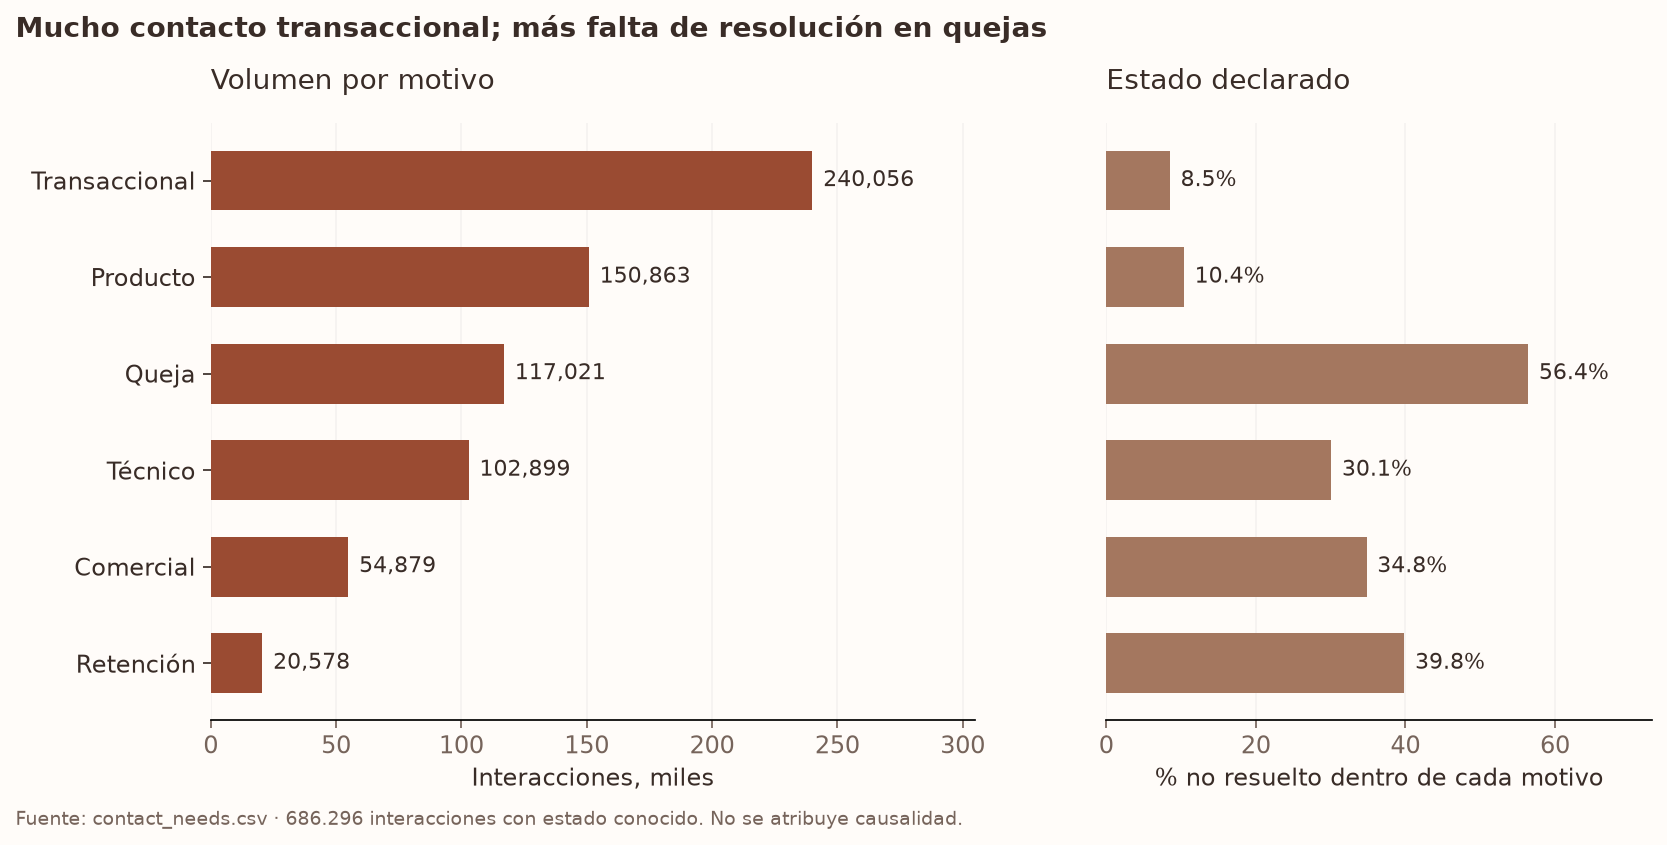

,reason,interactions,customers,unresolved,resolution_known,unresolved_pct,followups
0,Transaccional,240056,119646,20385,240056,8.491769,53137
1,Producto,150863,95245,15650,150863,10.373650,35923
2,Queja,117021,81336,66000,117021,56.400133,73686
3,Técnico,102899,74536,30940,102899,30.068319,41763
4,Comercial,54879,45979,19093,54879,34.791086,24446
5,Retención,20578,19274,8198,20578,39.838663,10099


,channel,interactions,customers
0,Phone,583250,146912
1,Email,27543,25181
2,App,26364,24197
3,WhatsApp,22888,21227
4,Web Chat,22856,21238
5,Web,3395,3363


,subcategory,cases,customers,sla_flagged,sla_known
0,Cargo no reconocido,12297,11818,2507,12297
1,Cobro indebido,12194,11722,2431,12194
2,Problema con app,12128,11648,2429,12128
3,Atención en sucursal,11892,11434,2421,11892
4,Calidad de servicio,11886,11477,2412,11886
5,(sin subcategoría),6698,6551,1295,6698


,promoted_product,campaigns
0,Tarjeta Crédito,52
1,Cuenta Ahorro,40
2,Préstamo Personal,28
3,(sin producto),22
4,Inversión,20
5,Cuenta Corriente,17
6,Préstamo Hipotecario,11
7,Seguro,10


In [5]:
c=frames['contact_needs'].sort_values('interactions')
fig,axes=plt.subplots(1,2,figsize=(12,5),gridspec_kw={'width_ratios':[1.4,1]})
b=axes[0].barh(c.reason,c.interactions/1000,color='#9A4B32',height=.62)
axes[0].bar_label(b,labels=[f'{n:,.0f}' for n in c.interactions],padding=5,fontsize=10)
axes[0].set_xlim(0,305);axes[0].set_xlabel('Interacciones, miles')
axes[0].set_title('Volumen por motivo',loc='left',pad=16)
b=axes[1].barh(c.reason,c.unresolved_pct,color='#A4775F',height=.62)
axes[1].bar_label(b,labels=[f'{n:.1f}%' for n in c.unresolved_pct],padding=5,fontsize=10)
axes[1].set_xlim(0,73);axes[1].set_yticks([]);axes[1].set_xlabel('% no resuelto dentro de cada motivo')
axes[1].set_title('Estado declarado',loc='left',pad=16)
for ax in axes: ax.grid(axis='x',alpha=.12);ax.set_axisbelow(True)
fig.suptitle('Mucho contacto transaccional; más falta de resolución en quejas',x=.02,ha='left',fontweight='bold',fontsize=13,y=1.02)
fig.text(.02,-.025,'Fuente: contact_needs.csv · 686.296 interacciones con estado conocido. No se atribuye causalidad.',fontsize=9,color='#76645B')
savefig(fig,'atencion.png')
display(frames['contact_needs'])
display(frames['contact_channels'])
display(frames['complaint_needs'])
display(frames['campaign_products'])

Queja y Técnico reúnen 96.940 de 160.266 interacciones no resueltas (60,49 %).
Las cinco subcategorías conocidas de reclamo rondan 12.000 casos cada una: no proclamar que una concentra
el problema. Las llamadas son 84,99 % de contactos; no demuestra que voz sea mejor que texto.

**Titularidad:** 44.570/44.570 reclamos con producto apuntan a otro titular;
1.094.226/1.094.242 eventos-producto comparables también discrepan.
Transacciones-productos concuerdan en 4.425.008 filas. No usar los vínculos malos como
hechos individuales ni mostrar datos ajenos en una sesión.
Campañas describen productos promocionados, no uso ni elegibilidad.
No se infieren tasas, aprobación, rentabilidad, fraude, devoluciones o políticas.

## Decisión incorporada
- Cuentas y tarjetas: productos propios, saldo y filtro.
- Movimientos: búsqueda, estado, detalle y revisión explícita.
- Transferencias, pagos y efectivo: consulta y solicitud con contexto.
- Préstamos, inversiones y seguros: consulta sin contratación.
- Solicitudes: confirmación, referencia, idempotencia, estado y derivación simulada.
- Agente: rutas permitidas ES/EN/PT, respuestas guiadas sin LLM.
- Admin: cola y auditoría protegidas por rol.

Los fixtures son nuevos, ficticios y coherentes. No se entrenó un modelo ni se midió impacto.
Ver docs/servicios-basados-en-datos.md para decisiones y límites.